# EDA del conjunto de actividad en SNC — Etapa 2

**Bioactive AI** · Equipo 7 · Maestría en Inteligencia Artificial Aplicada (TC5035.10)

El [Avance 1](01_EDA.html) exploró el conjunto de permeabilidad, que es la etapa 1. Este notebook hace lo mismo con el conjunto de **actividad sobre dianas del sistema nervioso central**, que alimenta la etapa 2.

La pregunta que responde la etapa 2 es: para un compuesto que llega al cerebro, ¿tiene actividad sobre alguna diana asociada a neuroprotección, y sobre cuál?

## Qué se busca aquí

1. **Cuántos compuestos hay de verdad**, no cuántas filas.
2. **Si las dos etapas se pueden encadenar**: cuántos compuestos tienen medición en ambos conjuntos.
3. **Cómo convertir mediciones en etiquetas**, que es la decisión más delicada del proyecto: la misma molécula es activa o inactiva según la concentración a la que se ensayó.

Los datos son los que entregó la patrocinadora el 25 de septiembre, con su diccionario de columnas.

## 1. Preparación

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
pd.set_option("display.width", 160)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROF = RAIZ / "data" / "external" / "profesora"
print("RDKit", Chem.rdBase.rdkitVersion)

RDKit 2026.03.6


## 2. Estructura de los datos

El archivo reúne registros de **tres fuentes** y por **dos rutas de selección** distintas, y esa distinción condiciona todo lo que sigue.

In [2]:
ACT = PROF / "snc_activity_crudo_v3_final_2026-09-25_Entrenamiento.csv"
d = pd.read_csv(ACT, low_memory=False)
d.columns = [c.strip().lstrip("\ufeff") for c in d.columns]

print(f"{len(d):,} registros x {d.shape[1]} columnas\n")
print("fuentes:")
print(d["source"].value_counts().to_string())
print("\nrutas de selección:")
print(d["selection_route"].value_counts().to_string())

202,647 registros x 40 columnas

fuentes:
source
chembl    187354
npass      11992
cmaup       3301

rutas de selección:
selection_route
cns_target        108640
neuronal_assay     93204
both                 803


`cns_target` son registros de actividad **contra una diana concreta** de la lista del proyecto. `neuronal_assay` son ensayos sobre **sistemas celulares neuronales** sin una diana molecular identificada: miden un fenotipo, no una interacción. Son dos tipos de evidencia distintos y conviene no mezclarlos sin decirlo.

In [3]:
# las columnas con huecos grandes, que es donde están las decisiones
faltantes = (1 - d.notna().mean()).sort_values(ascending=False) * 100
tabla = faltantes[faltantes > 0].to_frame("% faltante").round(1)
tabla["distintos"] = [d[c].nunique() for c in tabla.index]
print(tabla.to_string())

                              % faltante  distintos
compound_name                       98.4        822
chembl_data_validity_comment        97.4          2
assay_organism                      94.1         18
inchikey_source                     92.5       4480
chembl_standard_text_value          85.3          1
assay_cell_type_raw                 85.1        111
chembl_activity_comment             73.6      21314
assay_tissue_raw                    64.5         22
assay_format                        55.5          8
assay_type                          55.5          4
target_gene                         46.0         54
target_id_source                    44.2        116
target_type_source                  44.2         11
diana_enfermedades                  43.5         32
chembl_pchembl_value                36.2        765
activity_units                      14.7         13
activity_value                      14.7      17564
activity_relation                   14.7          8
assay_chembl

## 3. Cuántos compuestos hay, de verdad

La misma lección del Avance 1: el número de filas sobreestima la información independiente.

In [4]:
print(f"registros            : {len(d):,}")
print(f"source_compound_id   : {d['source_compound_id'].nunique():,}")
print(f"SMILES distintos     : {d['smiles_raw'].nunique():,}")

por_comp = d.groupby("source_compound_id").size()
print(f"\nregistros por compuesto: mediana {por_comp.median():.0f}, "
      f"media {por_comp.mean():.1f}, máximo {por_comp.max():,}")
print(f"compuestos con un solo registro: {(por_comp==1).sum():,} ({(por_comp==1).mean()*100:.1f}%)")

registros            : 202,647
source_compound_id   : 108,458
SMILES distintos     : 108,076

registros por compuesto: mediana 1, media 1.9, máximo 606
compuestos con un solo registro: 73,820 (68.1%)


In [5]:
# se recalcula la identidad química desde el SMILES, igual que en la etapa 1
unicos = d["smiles_raw"].dropna().unique()
mols = {s: Chem.MolFromSmiles(s) for s in unicos}
invalidos = [s for s, m in mols.items() if m is None]

ik = {s: Chem.MolToInchiKey(m) for s, m in mols.items() if m is not None}
esq = {s: k[:14] for s, k in ik.items()}

print(f"SMILES únicos          : {len(unicos):,}")
print(f"  no parsean en RDKit  : {len(invalidos):,} ({100*len(invalidos)/len(unicos):.2f}%)")
print(f"InChIKey completos     : {len(set(ik.values())):,}")
print(f"esqueletos de conectividad: {len(set(esq.values())):,}")
print(f"\n>> el tamaño efectivo es {len(set(esq.values())):,} estructuras, no {len(d):,} filas")

SMILES únicos          : 108,076
  no parsean en RDKit  : 8 (0.01%)
InChIKey completos     : 105,583
esqueletos de conectividad: 99,585

>> el tamaño efectivo es 99,585 estructuras, no 202,647 filas


Los 8 SMILES que no parsean son irrelevantes en proporción (0.01%), pero se descartan igual: una estructura que RDKit no puede leer tampoco puede generar descriptores.

La caída de 108,076 SMILES a 99,585 esqueletos es menos drástica que en la etapa 1 —ahí 7,805 filas eran 4,018 estructuras—, porque este conjunto tiene muchos más compuestos distintos y menos estereoisómeros repetidos.

## 4. ¿Se pueden encadenar las dos etapas?

Esta es la pregunta de diseño más importante del notebook. El pipeline supone que un compuesto pasa por la etapa 1 y después por la etapa 2. Para **validar** esa cadena de principio a fin hacen falta compuestos con medición en ambos conjuntos.

In [6]:
b = pd.read_csv(PROF / "bbb_permeability_experimental.csv")
b.columns = [c.strip().lstrip("\ufeff") for c in b.columns]

esq_bbb = set(b["key14"].dropna())
esq_act = set(esq.values())
comun = esq_bbb & esq_act

print(f"esqueletos en el conjunto de permeabilidad : {len(esq_bbb):,}")
print(f"esqueletos en el conjunto de actividad     : {len(esq_act):,}")
print(f"en AMBOS                                   : {len(comun):,}")
print(f"\n  = {100*len(comun)/len(esq_act):.1f}% de los de actividad")
print(f"  = {100*len(comun)/len(esq_bbb):.1f}% de los de permeabilidad")

esqueletos en el conjunto de permeabilidad : 4,019
esqueletos en el conjunto de actividad     : 99,585
en AMBOS                                   : 1,033

  = 1.0% de los de actividad
  = 25.7% de los de permeabilidad


**Solo 1,033 estructuras tienen medición en los dos conjuntos.** Es el 1.0% del conjunto de actividad.

Tres consecuencias directas:

1. **La cadena completa no se puede validar experimentalmente salvo en ese 1%.** Para los otros 98,552 compuestos con actividad medida, la permeabilidad tendría que ser *predicha* por el modelo de la etapa 1, con toda la incertidumbre que eso arrastra.
2. **Refuerza que la etapa 1 no opere como filtro duro.** Descartar compuestos con un BBB− predicho —no medido— eliminaría candidatos con actividad real documentada por una predicción que nadie verificó.
3. **Los 1,033 compuestos comunes son un activo**: son el único conjunto donde se puede medir si la cadena de dos etapas funciona. Conviene reservarlos como conjunto de evaluación del sistema completo, no gastarlos en entrenamiento.

In [7]:
# ¿qué aspecto tienen esos 1,033?
s2e = pd.Series(esq)
d["esqueleto"] = d["smiles_raw"].map(s2e)
en_ambos = d[d["esqueleto"].isin(comun)]

print(f"registros de actividad de esos compuestos: {len(en_ambos):,}")
print("\nsu clase de permeabilidad:")
print(b[b["key14"].isin(comun)]["bbb_class"].value_counts().to_string())
print("\nsus fuentes de actividad:")
print(en_ambos["source"].value_counts().to_string())

registros de actividad de esos compuestos: 30,016

su clase de permeabilidad:
bbb_class
BBB+    1249
BBB-     834

sus fuentes de actividad:
source
chembl    24301
npass      4222
cmaup      1493


## 5. Las dianas

La patrocinadora entregó una lista de **39 dianas** con su gen, su categoría de enfermedad, el mecanismo y el efecto que se busca.

In [8]:
dianas = pd.read_csv(PROF / "etiquetas_dianas_2026-09-25.csv")
dianas.columns = [c.strip().lstrip("\ufeff") for c in dianas.columns]
print(f"{len(dianas)} dianas definidas por la patrocinadora\n")
print(dianas.groupby("diana_categoria").size().sort_values(ascending=False).to_string())

39 dianas definidas por la patrocinadora

diana_categoria
Neuroinflamación               10
Alzheimer                       9
Epilepsia                       5
Parkinson                       5
Depresión                       2
ELA                             2
Estrés oxidativo                2
Ansiedad                        1
Deterioro cognitivo             1
Huntington                      1
Neurodegeneración (general)     1


In [9]:
con_diana = d[d["diana_categoria"] != "Sin diana de la lista"]
sin_diana = d[d["diana_categoria"] == "Sin diana de la lista"]

print(f"registros CON diana de la lista : {len(con_diana):,} ({100*len(con_diana)/len(d):.1f}%) · "
      f"{con_diana['source_compound_id'].nunique():,} compuestos")
print(f"registros SIN diana de la lista : {len(sin_diana):,} ({100*len(sin_diana)/len(d):.1f}%) · "
      f"{sin_diana['source_compound_id'].nunique():,} compuestos")
print(f"\nlos 'sin diana' entraron todos por: {dict(sin_diana['selection_route'].value_counts())}")
print("\ndistribución por enfermedad (solo los que tienen diana):")
print(con_diana["diana_categoria"].value_counts().to_string())

registros CON diana de la lista : 114,549 (56.5%) · 69,887 compuestos
registros SIN diana de la lista : 88,098 (43.5%) · 42,799 compuestos

los 'sin diana' entraron todos por: {'neuronal_assay': np.int64(88098)}

distribución por enfermedad (solo los que tienen diana):
diana_categoria
Alzheimer                      52676
Parkinson                      32372
Neuroinflamación               12331
Depresión                      10888
Estrés oxidativo                2456
Epilepsia                       1862
Neurodegeneración (general)     1110
Deterioro cognitivo              488
Ansiedad                         160
Huntington                       153
ELA                               53


**El 43.5% de los registros no corresponde a ninguna diana de la lista.** No son basura: entraron por la ruta `neuronal_assay`, es decir, son ensayos sobre células neuronales donde se midió un efecto sin identificar la proteína responsable.

Es evidencia fenotípica, y sirve para otra pregunta —¿este compuesto hace *algo* en un sistema neuronal?— pero no para la que plantea la etapa 2, que es predecir actividad **sobre una diana concreta**. Mezclarlas produciría un modelo que no sabe qué está prediciendo.

**Decisión propuesta:** la etapa 2 se entrena sobre los 114,549 registros con diana identificada. Los 88,098 restantes se conservan como conjunto separado para una pregunta distinta, no se descartan.

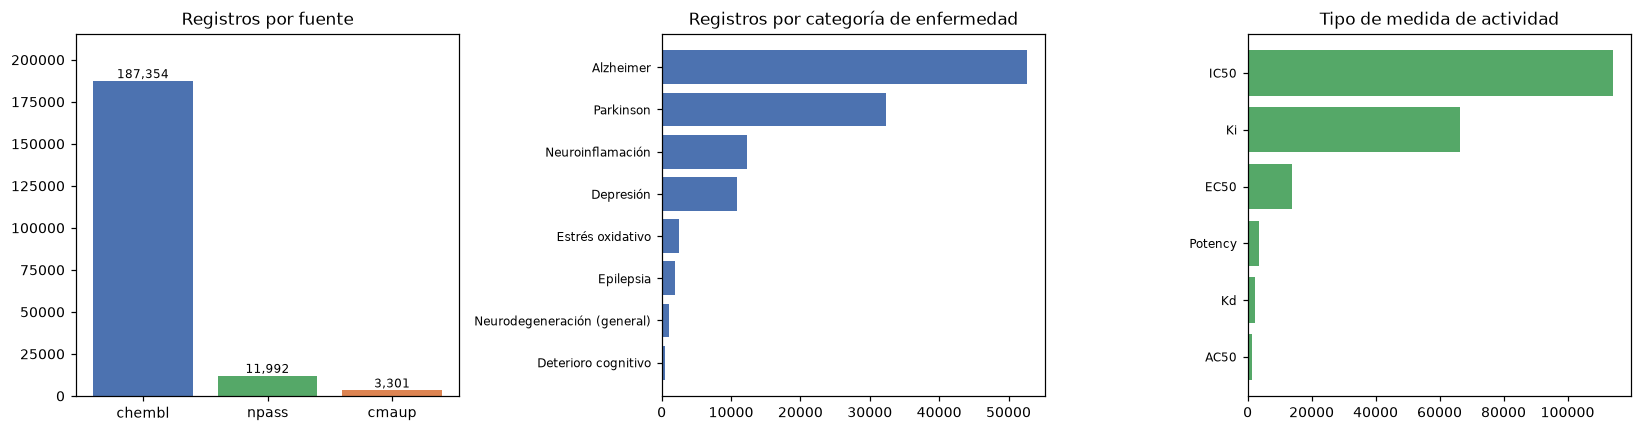

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

v = d["source"].value_counts()
axes[0].bar(range(len(v)), v.values, color=["#4C72B0","#55A868","#DD8452"])
axes[0].set_xticks(range(len(v))); axes[0].set_xticklabels(v.index)
for i, x in enumerate(v.values): axes[0].text(i, x, f"{x:,}", ha="center", va="bottom", fontsize=8)
axes[0].set_title("Registros por fuente"); axes[0].set_ylim(0, v.max()*1.15)

c = con_diana["diana_categoria"].value_counts().head(8)[::-1]
axes[1].barh(range(len(c)), c.values, color="#4C72B0")
axes[1].set_yticks(range(len(c))); axes[1].set_yticklabels(c.index, fontsize=8)
axes[1].set_title("Registros por categoría de enfermedad")

t = d["activity_type"].value_counts().head(6)[::-1]
axes[2].barh(range(len(t)), t.values, color="#55A868")
axes[2].set_yticks(range(len(t))); axes[2].set_yticklabels(t.index, fontsize=8)
axes[2].set_title("Tipo de medida de actividad")
plt.tight_layout(); plt.show()

## 6. El problema del etiquetado

Aquí está la decisión más delicada del proyecto. `CLAUDE.md` fija el criterio en **pChEMBL ≥ 5** como etiqueta primaria y **≥ 6** como prueba de robustez. Al aplicarlo sobre estos datos aparecen tres problemas que el criterio por sí solo no resuelve.

### 6.1 El pChEMBL solo existe para una de las tres fuentes

In [11]:
print(d.groupby("source")["chembl_pchembl_value"]
        .agg(registros="size", con_pchembl="count")
        .assign(**{"% con pChEMBL": lambda x: (100*x.con_pchembl/x.registros).round(1)})
        .to_string())

nat = d["source"].isin(["npass", "cmaup"])
print(f"\nregistros de NPASS y CMAUP (productos naturales): {nat.sum():,}")
print(f"compuestos distintos en esas fuentes            : {d.loc[nat,'source_compound_id'].nunique():,}")
print(f"de ellos, con pChEMBL                           : {d.loc[nat,'chembl_pchembl_value'].notna().sum():,}")

        registros  con_pchembl  % con pChEMBL
source                                       
chembl     187354       129243           69.0
cmaup        3301            0            0.0
npass       11992            0            0.0

registros de NPASS y CMAUP (productos naturales): 15,293
compuestos distintos en esas fuentes            : 4,482
de ellos, con pChEMBL                           : 0


**Ninguno de los 15,293 registros de NPASS y CMAUP trae pChEMBL.** El pChEMBL es un campo que calcula ChEMBL; las otras dos bases no lo publican.

Esto importa mucho más de lo que parece. NPASS y CMAUP son **bases de productos naturales**, y los productos naturales son justamente los compuestos que el proyecto quiere priorizar. Etiquetar solo con pChEMBL deja fuera, en silencio, a los 4,482 compuestos naturales del conjunto.

Es el mismo patrón que apareció en el Avance 1 con las categorías A–D: un criterio que parece técnico y neutro resulta estar correlacionado con justo lo que se quiere estudiar.

### 6.2 Un cuarto de las mediciones está censurado

In [12]:
censura = d["activity_relation_used"].isin([">=", ">", ">>", ">=="])
print(d["activity_relation_used"].value_counts().to_string())
print(f"\nrelaciones censuradas (>=, >, >>): {censura.sum():,} ({100*censura.mean():.1f}%)")
print(f"de esas, con pChEMBL              : {d.loc[censura,'chembl_pchembl_value'].notna().sum():,}")

activity_relation_used
=     146136
>      54377
<       1834
<=       128
>=       118
~         51
>>         3

relaciones censuradas (>=, >, >>): 54,498 (26.9%)
de esas, con pChEMBL              : 0


Una medida de `>= 10000 nM` no dice *cuánto* vale la actividad: dice que **no se detectó efecto hasta esa concentración**. Es información real —y casi siempre significa inactivo— pero no es un número con el que se pueda calcular un pChEMBL.

Y en efecto: **ninguno de los 54,498 registros censurados trae pChEMBL**. Filtrar por pChEMBL no solo descarta los productos naturales, también descarta la mayor parte de la evidencia de inactividad.

### 6.3 Hay 29,730 inactivos que solo existen como texto

In [13]:
print(d.groupby(["evidence_kind", "relation_origin"]).size().to_string())
print("\ncomentarios más frecuentes en los 'inactivo_por_texto':")
print(d.loc[d.evidence_kind == "inactivo_por_texto", "chembl_activity_comment"]
       .dropna().value_counts().head(3).to_string())

evidence_kind       relation_origin
concentracion       fuente             170916
                    inferida             2001
inactivo_por_texto  texto_chembl        29730

comentarios más frecuentes en los 'inactivo_por_texto':
chembl_activity_comment
Inhibition < 50% @ 10 uM and thus dose-reponse curve not measured    29730


Son registros donde el artículo original dice algo como *«Inhibition < 50% @ 10 uM»*: el compuesto se ensayó, no funcionó, y nadie midió una curva dosis-respuesta. La curación de la patrocinadora los rescató como inactivos explícitos.

**Son la mejor fuente de negativos del conjunto**, y también quedan fuera si se etiqueta solo con pChEMBL.

### 6.4 El umbral cambia el problema, no solo la frontera

In [14]:
e = d[d["chembl_pchembl_value"].notna()]
filas = []
for u in [4, 5, 6, 7]:
    act = e["chembl_pchembl_value"] >= u
    filas.append({"umbral": f"pChEMBL >= {u}", "activos": act.sum(), "inactivos": (~act).sum(),
                  "% activos": round(100*act.mean(), 1),
                  "razón": f"{act.sum()/max((~act).sum(),1):.1f}:1"})
print(pd.DataFrame(filas).to_string(index=False))
print(f"\n(sobre los {len(e):,} registros que tienen pChEMBL)")

      umbral  activos  inactivos  % activos   razón
pChEMBL >= 4   129110        133       99.9 970.8:1
pChEMBL >= 5   112515      16728       87.1   6.7:1
pChEMBL >= 6    82304      46939       63.7   1.8:1
pChEMBL >= 7    49645      79598       38.4   0.6:1

(sobre los 129,243 registros que tienen pChEMBL)


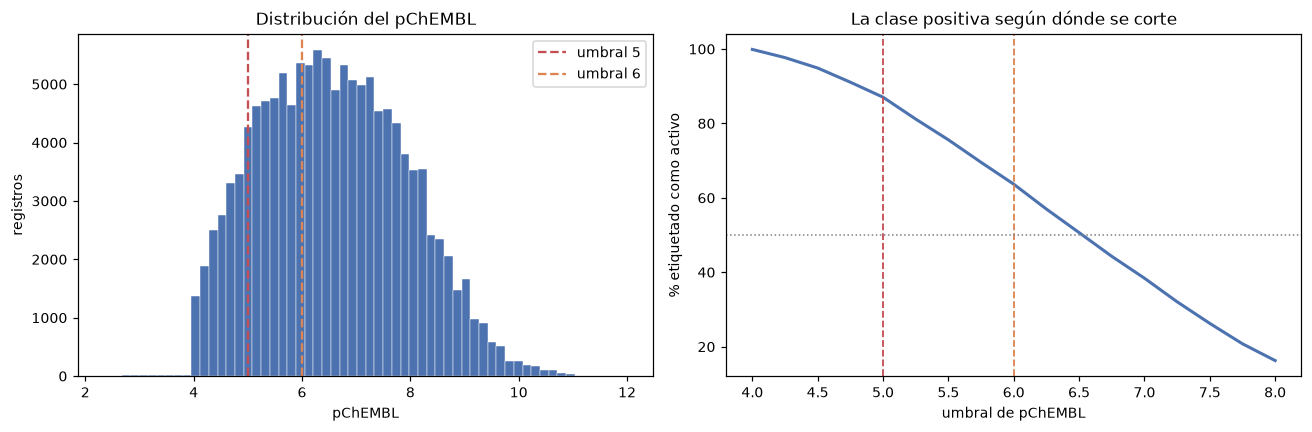

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(e["chembl_pchembl_value"].dropna(), bins=60, color="#4C72B0", edgecolor="white", linewidth=.3)
for u, col in [(5, "#C44E52"), (6, "#DD8452")]:
    axes[0].axvline(u, color=col, ls="--", lw=1.5, label=f"umbral {u}")
axes[0].set_xlabel("pChEMBL"); axes[0].set_ylabel("registros")
axes[0].set_title("Distribución del pChEMBL"); axes[0].legend()

us = np.arange(4, 8.01, 0.25)
pct = [100*(e["chembl_pchembl_value"] >= u).mean() for u in us]
axes[1].plot(us, pct, color="#4C72B0", lw=2)
for u, col in [(5, "#C44E52"), (6, "#DD8452")]:
    axes[1].axvline(u, color=col, ls="--", lw=1.2)
axes[1].axhline(50, color="gray", ls=":", lw=1)
axes[1].set_xlabel("umbral de pChEMBL"); axes[1].set_ylabel("% etiquetado como activo")
axes[1].set_title("La clase positiva según dónde se corte")
plt.tight_layout(); plt.show()

La distribución del pChEMBL está centrada en 6.5, así que los dos umbrales candidatos caen en plena masa de los datos, no en una cola:

- **pChEMBL ≥ 5** deja el 87.1% de activos: un desbalance de 6.7 a 1 donde la clase difícil es la inactiva.
- **pChEMBL ≥ 6** deja el 63.7%: un desbalance de 1.8 a 1, mucho más tratable.

No hay un mínimo natural en la distribución que sugiera dónde cortar. **El umbral es una decisión del proyecto, no un hecho de los datos**, y el Avance 1 ya mostró con el TPSA lo que pasa cuando un umbral derivado de un subconjunto se presenta como constante.

## 7. Unidades y conversión

In [16]:
print(d["activity_units_used"].value_counts().to_string())
molar = ["nM", "uM", "um", "M", "mM", "pM", "10^3nM", "10^2 uM", "10^6uM", "umol/L"]
no_molar = d[~d["activity_units_used"].isin(molar)]
print(f"\nregistros en unidades de masa, no convertibles sin peso molecular: {len(no_molar):,}")
print("  " + ", ".join(f"{k}={v}" for k, v in no_molar["activity_units_used"].value_counts().items()))

activity_units_used
nM         172037
uM          29880
ug.mL-1       535
ug ml-1       114
10^3nM         27
um             23
10^2 uM        14
pg/ml          12
10^6uM          1
M               1
ng/L            1
mM              1
umol/L          1

registros en unidades de masa, no convertibles sin peso molecular: 662
  ug.mL-1=535, ug ml-1=114, pg/ml=12, ng/L=1


La gran mayoría está en nanomolar o micromolar, que se convierten entre sí sin problema. Los 662 registros en µg/mL necesitan el peso molecular del compuesto para pasar a molar — se puede calcular desde el SMILES con RDKit, así que es trabajo, no un bloqueo.

## 8. Conclusiones

### 8.1 Las dos etapas casi no comparten compuestos

De los 99,585 esqueletos con actividad medida, **solo 1,033 tienen también medición de permeabilidad**: el 1.0%. La cadena completa del pipeline no se puede validar experimentalmente más que sobre ese subconjunto.

Esto confirma por una vía independiente la decisión de diseño que ya estaba tomada: **la etapa 1 no puede operar como filtro duro**. Para el 99% de los compuestos con actividad documentada, su permeabilidad sería una predicción sin verificar, y descartarlos con ella eliminaría candidatos reales.

Los 1,033 compuestos comunes conviene reservarlos para evaluar el sistema de dos etapas completo, en vez de gastarlos en entrenamiento.

### 8.2 El criterio de etiquetado excluye justo lo que el proyecto quiere estudiar

Etiquetar con pChEMBL, que es el criterio documentado hasta ahora, descarta en silencio:

| Qué se pierde | Registros |
|---|---|
| Todo NPASS y CMAUP, las bases de **productos naturales** | 15,293 |
| Todas las mediciones **censuradas** (`>= X nM`) | 54,498 |
| Todos los **inactivos declarados por texto** | 29,730 |

Son tres pérdidas distintas y las tres apuntan en la misma dirección: se queda la evidencia de ChEMBL con curva dosis-respuesta, que está sesgada hacia compuestos sintéticos bien caracterizados.

**Propuesta:** etiquetar en dos niveles explícitos. El pChEMBL donde exista, y una regla de concentración sobre `activity_value_used` para el resto, tratando la censura como inactivo cuando el umbral ensayado es alto. Hay que documentar cuántos compuestos entran por cada vía y reportar el desempeño por separado.

### 8.3 El umbral es una decisión, no un dato

pChEMBL ≥ 5 deja 87.1% de activos; ≥ 6 deja 63.7%. La distribución no tiene un mínimo que sugiera dónde cortar, así que el corte lo pone el proyecto.

**Recomendación: usar ≥ 6 como primario y ≥ 5 como robustez**, al revés de lo que dice hoy `CLAUDE.md`. Con ≥ 5 el desbalance es de 6.7 a 1 y la clase minoritaria es la inactiva, que es la más difícil de aprender y la que menos ejemplos tendría.

### 8.4 Hay dos tipos de evidencia mezclados

El 43.5% de los registros no corresponde a ninguna diana de la lista: son ensayos fenotípicos sobre células neuronales, que entraron por la ruta `neuronal_assay`. Miden que algo pasa, no sobre qué proteína.

La etapa 2 debería entrenarse sobre los **114,549 registros con diana identificada**. Los 88,098 restantes se conservan para una pregunta distinta — actividad fenotípica— y no se descartan.

### 8.5 Siguientes pasos

1. Fijar la regla de etiquetado en dos niveles y contar cuántos compuestos entran por cada vía.
2. Convertir los 662 registros en µg/mL a molar usando el peso molecular de RDKit.
3. Decidir la agregación cuando un mismo compuesto tiene varias medidas sobre la misma diana: el criterio documentado es quedarse con la más potente.
4. Reservar los 1,033 compuestos comunes con la etapa 1 como conjunto de evaluación del sistema completo.
5. Construir la partición por andamio, igual que en la etapa 1, con la verificación de fuga ya implementada en `src/data_prep/splits.py`.